In [5]:
import pandas as pd

df = pd.read_csv("Dataset .csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (9551, 21)

Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
print(df['Cuisines'].head(20))

0             French, Japanese, Desserts
1                               Japanese
2       Seafood, Asian, Filipino, Indian
3                        Japanese, Sushi
4                       Japanese, Korean
5                                Chinese
6                        Asian, European
7     Seafood, Filipino, Asian, European
8                European, Asian, Indian
9                               Filipino
10                     Filipino, Mexican
11         American, Ice Cream, Desserts
12                     Filipino, Mexican
13                              Filipino
14                                Korean
15     Cafe, American, Italian, Filipino
16                        Italian, Pizza
17                              Filipino
18                Cafe, Korean, Desserts
19       Cafe, Bakery, American, Italian
Name: Cuisines, dtype: object


In [7]:
print("Missing cuisines:", df['Cuisines'].isnull().sum())

Missing cuisines: 9


In [8]:
print("Number of unique cuisine values:",
      df['Cuisines'].nunique())

Number of unique cuisine values: 1825


In [9]:
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

df['Cuisine_Category'] = df['Cuisines'].apply(
    lambda x: x.split(',')[0].strip()
)

print(df[['Cuisines', 'Cuisine_Category']].head(20))

                              Cuisines Cuisine_Category
0           French, Japanese, Desserts           French
1                             Japanese         Japanese
2     Seafood, Asian, Filipino, Indian          Seafood
3                      Japanese, Sushi         Japanese
4                     Japanese, Korean         Japanese
5                              Chinese          Chinese
6                      Asian, European            Asian
7   Seafood, Filipino, Asian, European          Seafood
8              European, Asian, Indian         European
9                             Filipino         Filipino
10                   Filipino, Mexican         Filipino
11       American, Ice Cream, Desserts         American
12                   Filipino, Mexican         Filipino
13                            Filipino         Filipino
14                              Korean           Korean
15   Cafe, American, Italian, Filipino             Cafe
16                      Italian, Pizza          

In [10]:
print(
    df['Cuisine_Category']
    .value_counts()
    .head(15)
)

Cuisine_Category
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64


In [11]:
# Select input features
features = [
    'City',
    'Average Cost for two',
    'Price range',
    'Aggregate rating',
    'Votes',
    'Has Table booking',
    'Has Online delivery'
]

X = df[features].copy()
y = df['Cuisine_Category'].copy()

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Input features:
['City', 'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes', 'Has Table booking', 'Has Online delivery']

Target:
Cuisine_Category

Feature shape: (9551, 7)
Target shape: (9551,)


In [12]:
print(X.isnull().sum())

City                    0
Average Cost for two    0
Price range             0
Aggregate rating        0
Votes                   0
Has Table booking       0
Has Online delivery     0
dtype: int64


In [13]:
X['City'] = X['City'].fillna('Unknown')

X['Has Table booking'] = X['Has Table booking'].fillna('No')
X['Has Online delivery'] = X['Has Online delivery'].fillna('No')

X['Average Cost for two'] = X['Average Cost for two'].fillna(
    X['Average Cost for two'].median()
)

X['Price range'] = X['Price range'].fillna(
    X['Price range'].median()
)

X['Aggregate rating'] = X['Aggregate rating'].fillna(
    X['Aggregate rating'].median()
)

X['Votes'] = X['Votes'].fillna(
    X['Votes'].median()
)

print("Missing values after cleaning:")
print(X.isnull().sum())

Missing values after cleaning:
City                    0
Average Cost for two    0
Price range             0
Aggregate rating        0
Votes                   0
Has Table booking       0
Has Online delivery     0
dtype: int64


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'City',
    'Has Table booking',
    'Has Online delivery'
]

numerical_features = [
    'Average Cost for two',
    'Price range',
    'Aggregate rating',
    'Votes'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_features)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (9551, 149)


In [16]:
from sklearn.model_selection import train_test_split
import numpy as np

# Create target variable
y = df['Cuisine_Category'].copy()

# Count restaurants in each cuisine
cuisine_counts = y.value_counts()

# Keep cuisines with at least 5 restaurants
valid_cuisines = cuisine_counts[cuisine_counts >= 5].index

# Create boolean mask
mask = y.isin(valid_cuisines)

# Convert mask to NumPy array
mask_array = mask.to_numpy()

# Filter encoded features and target
X_filtered = X_encoded[mask_array]
y_filtered = y[mask_array]

print("Original dataset:", len(y))
print("After removing rare cuisines:", len(y_filtered))
print("Number of cuisine classes:", y_filtered.nunique())

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.20,
    random_state=42,
    stratify=y_filtered
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Original dataset: 9551
After removing rare cuisines: 9453
Number of cuisine classes: 72

Training samples: 7562
Testing samples: 1891


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [18]:
# Make predictions
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 1891


In [19]:
comparison = pd.DataFrame({
    'Actual Cuisine': y_test.values,
    'Predicted Cuisine': y_pred
})

comparison.head(20)

,Actual Cuisine,Predicted Cuisine
0,Italian,Italian
1,Continental,Continental
2,Street Food,Fast Food
3,North Indian,North Indian
4,Bakery,North Indian
5,Chinese,North Indian
6,Chinese,Chinese
7,North Indian,Mughlai
8,Continental,North Indian
9,American,North Indian


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Accuracy: 0.2787
Accuracy (%): 27.87 %


In [21]:
from sklearn.metrics import classification_report

print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

===== CLASSIFICATION REPORT =====
                precision    recall  f1-score   support

       Afghani       0.00      0.00      0.00         1
      American       0.14      0.14      0.14        56
       Arabian       0.00      0.00      0.00         1
         Asian       0.12      0.07      0.09        15
        Awadhi       0.00      0.00      0.00         1
           BBQ       0.00      0.00      0.00         4
        Bakery       0.15      0.13      0.14       124
      Bar Food       0.00      0.00      0.00         2
       Bengali       0.00      0.00      0.00         4
     Beverages       0.06      0.06      0.06        16
       Biryani       0.00      0.00      0.00        22
     Brazilian       1.00      0.25      0.40         4
     Breakfast       0.00      0.00      0.00         5
       British       0.00      0.00      0.00         2
        Burger       0.05      0.04      0.05        23
          Cafe       0.26      0.30      0.28       124
       Chines

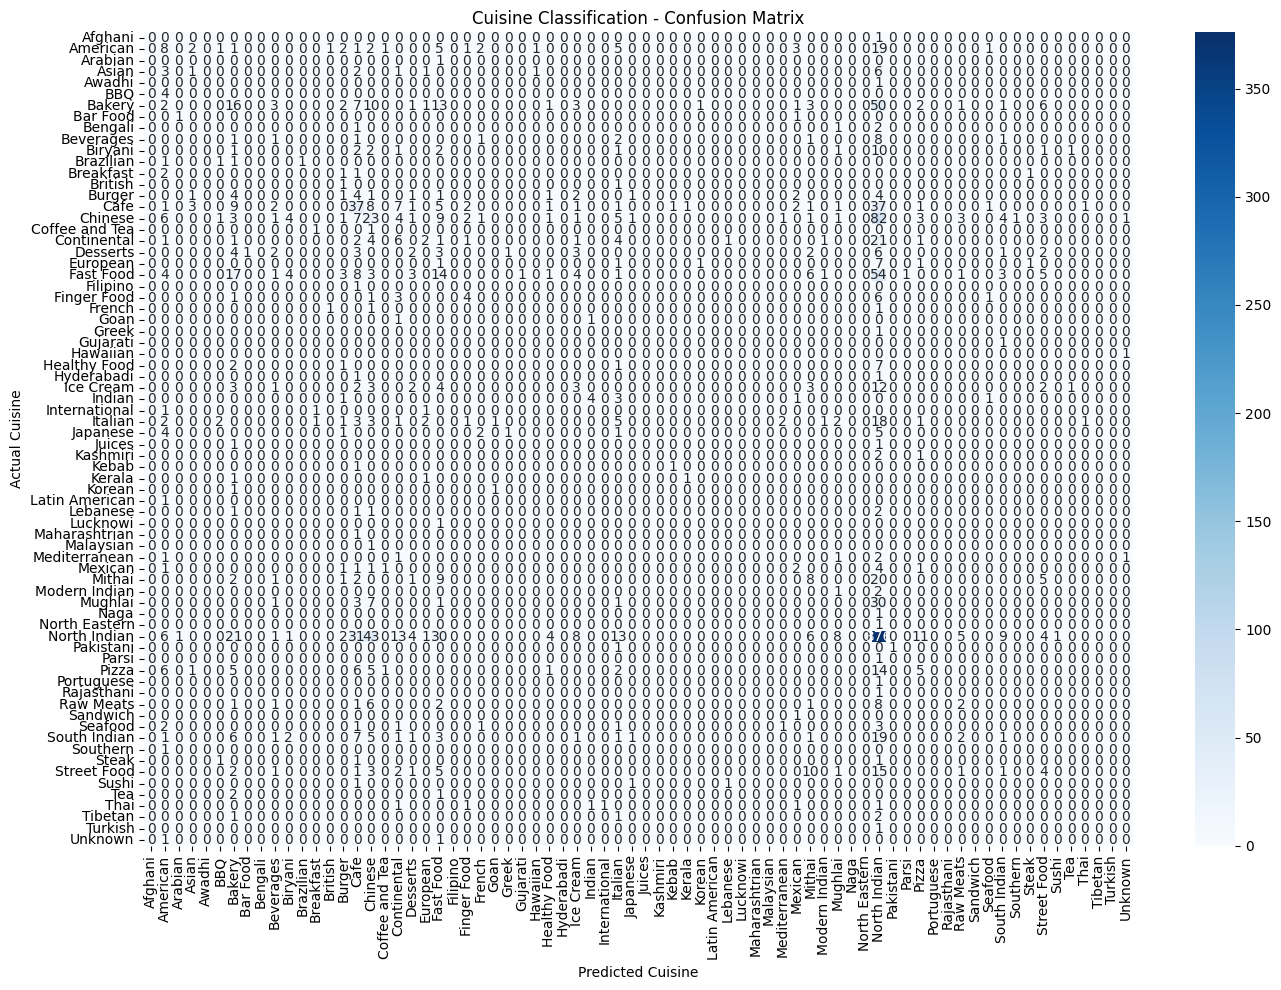

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.xlabel("Predicted Cuisine")
plt.ylabel("Actual Cuisine")
plt.title("Cuisine Classification - Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=rf_model.classes_,
    zero_division=0
)

cuisine_performance = pd.DataFrame({
    'Cuisine': rf_model.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Test Samples': support
})

cuisine_performance = cuisine_performance.sort_values(
    'F1 Score',
    ascending=False
)

cuisine_performance

,Cuisine,Precision,Recall,F1 Score,Test Samples
54,Pakistani,1.000000,0.500000,0.666667,2
53,North Indian,0.433679,0.627713,0.512960,599
38,Kebab,0.500000,0.500000,0.500000,2
32,Indian,0.666667,0.400000,0.500000,10
39,Kerala,0.500000,0.333333,0.400000,3
...,...,...,...,...,...
67,Tea,0.000000,0.000000,0.000000,3
68,Thai,0.000000,0.000000,0.000000,6
69,Tibetan,0.000000,0.000000,0.000000,4
70,Turkish,0.000000,0.000000,0.000000,1


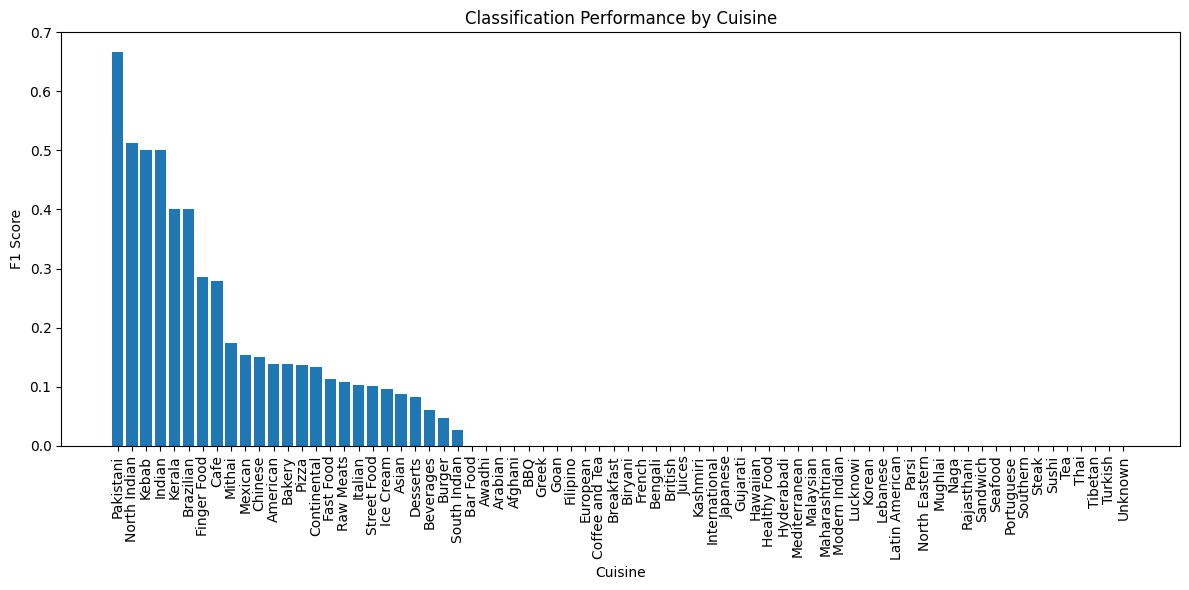

In [24]:
plt.figure(figsize=(12, 6))

plt.bar(
    cuisine_performance['Cuisine'],
    cuisine_performance['F1 Score']
)

plt.xlabel("Cuisine")
plt.ylabel("F1 Score")
plt.title("Classification Performance by Cuisine")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [25]:
best_cuisines = cuisine_performance.head(5)
worst_cuisines = cuisine_performance.tail(5)

print("===== TOP PERFORMING CUISINES =====")
display(best_cuisines)

print("\n===== LOWEST PERFORMING CUISINES =====")
display(worst_cuisines)

===== TOP PERFORMING CUISINES =====


,Cuisine,Precision,Recall,F1 Score,Test Samples
54,Pakistani,1.000000,0.500000,0.666667,2
53,North Indian,0.433679,0.627713,0.512960,599
38,Kebab,0.500000,0.500000,0.500000,2
32,Indian,0.666667,0.400000,0.500000,10
39,Kerala,0.500000,0.333333,0.400000,3



===== LOWEST PERFORMING CUISINES =====


,Cuisine,Precision,Recall,F1 Score,Test Samples
67,Tea,0.0,0.0,0.0,3
68,Thai,0.0,0.0,0.0,6
69,Tibetan,0.0,0.0,0.0,4
70,Turkish,0.0,0.0,0.0,1
71,Unknown,0.0,0.0,0.0,2
